### This notebook covers
1. Getting UVW from baselines in ENU and source in AltAz, and baselines in ITRS and source in HA/Dec (this is very often confusing and I havent seen this derived explicitly before.)
2. Rotation synthesis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz,TETE
from astropy.time import Time
import radio_tools as rt
import astropy.units as u

Now that we're familiar with fringes, let's actually compute the UV coverage for the array.
Remember that UV plane is defined in the direction of the source, with U pointing local east and V local north on the celestial sphere.

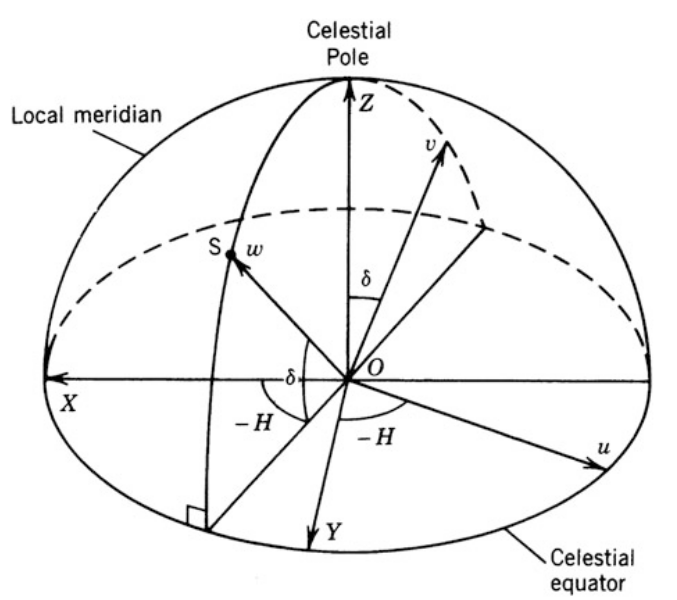

### This image shows a geocentric system. Why have we been using Astropy's slow altaz all this time?

We have to be careful in interpreting the image from TMS. image centers XYZ at local meridian, however our baselines are defined with X along longitude 0 which is Greenwich.

Next, the image shows that Earth's pole aligned with north celestial  pole. That would have been the case only (to within 10-20 mas) only on Jan 1, 2000. Earth's axis has precessed by 10-15' since then with respect to International Celestial Reference Frame. So, you might think that source positions at two different times in a Earth Centered Earth Fixed (ECEF) frame simply differ by a rotation along $\phi$ (hour angle or longitude on a sphere), but that's not quite right. The source will wobble slightly.

When you ask astropy to go from source position in ICRS to observed position in a topocentric system, effects like parallax, annual abberation, deflection of light by the sun, Earth's precession and nutation, and polar motion (movement of Earth's crust.) are all taken into account. The biggest is precession, all others can add 10s of arcseconds, which matters when doing VLBI.

In this notebook, we will see how to grid visibilities on to UV plane starting from baselines in ENU and source in alt-az, and also with baselines in XYZ and sources in HA,Dec.

In [2]:
hera = np.genfromtxt(
    "hera_ant_pos.csv",
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8"
)
hera_xyz = np.asarray([hera['x'],hera['y'],hera['z']]).T.copy() # xyz along columns
hera_ref = EarthLocation.from_geodetic(lat='−30.72152612068925°', lon='21.42830382686301°',height='1051.69 m')
hera_enu = rt.itrs_to_enu(hera_xyz, hera_ref.lat.deg, hera_ref.lon.deg)
nant = hera_xyz.shape[0]
ix = np.triu_indices(nant,k=1)
hera_bl_enu = hera_enu[ix[1]]-hera_enu[ix[0]]

tstart = 1753200150 #random datetime, you can choose your favorite, just make sure the source is risen!
obstime=Time(tstart,format="unix",scale="utc")
cenA = SkyCoord(ra='13h 25m 27.6150s',dec='−43° 01′ 08.806″', frame='icrs') 
azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
print("new az alt", azalt_cenA.az.deg, azalt_cenA.alt.deg)

new az alt 183.29482826319708 77.54182223021188


In [3]:
# Let's say it's operating at 150 MHz, and each dish is 14 m wide.
# what's the FoV of one dish, and what's the rough resolution of the array?
nu=150e6
lm = 3e8/nu #m
d = 14 #m dish size
max_bl = np.max(np.sqrt(np.sum(hera_bl_enu**2,axis=1)))
res = lm/max_bl #max baseline
fov = lm/d

print(f"Synth. beam res\t: {np.rad2deg(res)*60:4.2f} arcmin\nFOV\t\t: {np.rad2deg(fov):4.2f} deg")

Synth. beam res	: 7.84 arcmin
FOV		: 8.19 deg


In [4]:
#Projecting baseline in ENU to uvw where w is along the source. I will build the change of basis matrix explicitly
#This is a useful derivation that you will not find in TMS.

sin_az = np.sin(azalt_cenA.az.rad)
cos_az = np.cos(azalt_cenA.az.rad)
sin_alt = np.sin(azalt_cenA.alt.rad)
cos_alt = np.cos(azalt_cenA.alt.rad)

W = np.asarray([sin_az*cos_alt, cos_az*cos_alt, sin_alt]) 

# NCP is true North tilted up by Latitude (Z-axis)
NCP = np.array([0, np.cos(hera_ref.lat.rad), np.sin(hera_ref.lat.rad)])

# Standard astronomical U is orthogonal to NCP and W (see image above)
U = np.cross(NCP, W)
U /= np.linalg.norm(U) # Normalize

V= np.cross(W, U)

mat1 = np.vstack([U, V, W]).T
hera_uvw1 = hera_bl_enu @ mat1 / lm


In [5]:
# Get baselines in geocentric system (no ENU)
hera_bl_xyz = hera_xyz[ix[1]]-hera_xyz[ix[0]]

# Convert this AltAz to HA/Dec using spherical trig
ha,dec = rt.azalt_to_hadec(azalt_cenA.az.rad, azalt_cenA.alt.rad, hera_ref.lat.rad)
# This is APPARENT HA

gha = ha - hera_ref.lon.rad #hour angle at greenwich at this time
print(gha,dec)
sin_gha = np.sin(gha)
cos_gha = np.cos(gha)
sin_dec = np.sin(dec)
cos_dec = np.cos(dec)


W= np.asarray([cos_gha*cos_dec, -sin_gha*cos_dec, sin_dec])
U= np.asarray([sin_gha, cos_gha, 0])
V = np.cross(W,U)
mat2 = np.vstack([U,V,W]).T
hera_uvw2 = hera_bl_xyz@mat2/lm

-0.3569974832047039 -0.7532076994182199


Text(0, 0.5, 'V (wavelengths)')

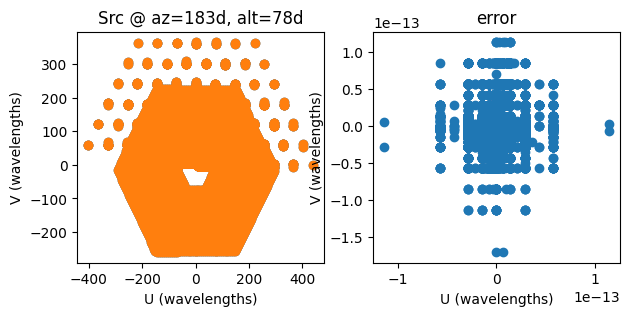

In [6]:
f=plt.figure(figsize=(7,3))
plt.subplot(121)
plt.scatter(hera_uvw1[:,0], hera_uvw1[:,1])
plt.scatter(hera_uvw2[:,0], hera_uvw2[:,1])
plt.title(f"Src @ az={azalt_cenA.az.deg:.0f}d, alt={azalt_cenA.alt.deg:.0f}d")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

plt.subplot(122)
plt.scatter(hera_uvw1[:,0]-hera_uvw2[:,0], hera_uvw1[:,1]-hera_uvw2[:,1])
plt.title(f"error")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

In the rest of this notebook, we will assume that we can evolve the source position in ECEF by just rotating along hour angle. Not strictly true but suffices our demonstration.

### Gridding

We want to image. Want to grid UV coverage onto a regular FFT grid.

What grid spacing in uv?
What size of grid?

Remember time-domain examples. Frequency resolution is the 1/longest timescale you measure. And total extent (-ve to +ve) in frequency is the 1/smallest timescale you measure = sampling rate. Same idea but our fourier duals are pixels of the image on the sky and uv points on the UV plane.

Grid spacing $\Delta u$ set by the patch size we want to image ~ 1/full-width of primary beam.

Grid size $u_{max}$ set by the image resolution we want ~ 1/synthesized beam.

In [7]:
def grid_uv(uv,du,npix):
    
    S = np.zeros((npix,npix),dtype='float64')
    uv_int = np.round(uv/du).astype(int)
    for i in range(uv.shape[0]):
        S[uv_int[i,0],uv_int[i,1]] +=1
        #image is a real field. So it's FFT must be hermitian symmetric
        S[-uv_int[i,0],-uv_int[i,1]] +=1
    return S

In [8]:
du=1/fov
umax=1/res
npix = int(fov/res)
#it's generally better to over-sample the image to avoid pixelization effects. Rule of thumb is 3 pixels per beamwidth.
npix *= 3
img_res = res/3
gridded_uv = grid_uv(hera_uvw1[:,:2], du, npix)

In [9]:
img = np.fft.ifft2(gridded_uv).real

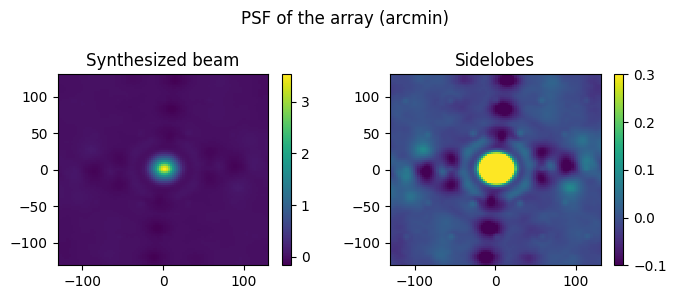

In [10]:
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("PSF of the array (arcmin)")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()

### What happens when the source is really low in the sky?

new actual az alt 222.11984250452292 5.53945633698941
new estimated az alt [222.13481886   5.55843854]
Remember it won't like up exactly because we are evolving by rotating along NCP


Text(0, 0.5, 'V (wavelengths)')

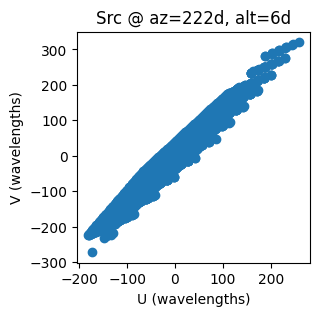

In [11]:
tstart = 1753200150 + 27000

#new hour angle is
gha2 = gha + 27000*7.29e-5 # rot vel of earth in rad/s

obstime=Time(tstart,format="unix",scale="utc")
azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
print("new actual az alt", azalt_cenA.az.deg, azalt_cenA.alt.deg)
print("new estimated az alt", np.rad2deg(rt.hadec_to_azalt(gha2+hera_ref.lon.rad, dec, hera_ref.lat.rad))) # local HA = GHA + Lon
print("Remember it won't like up exactly because we are evolving by rotating along NCP")

sin_gha = np.sin(gha2)
cos_gha = np.cos(gha2)


W= np.asarray([cos_gha*cos_dec, -sin_gha*cos_dec, sin_dec])
U= np.asarray([sin_gha, cos_gha, 0])
V = np.cross(W,U)
mat2 = np.vstack([U,V,W]).T
hera_uvw2 = hera_bl_xyz@mat2/lm

f=plt.figure(figsize=(3,3))
plt.scatter(hera_uvw2[:,0], hera_uvw2[:,1])
plt.title(f"Src @ az={azalt_cenA.az.deg:.0f}d, alt={azalt_cenA.alt.deg:.0f}d")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

In [12]:
gridded_uv = grid_uv(hera_uvw2[:,:2], du, npix)
img = np.fft.ifft2(gridded_uv).real

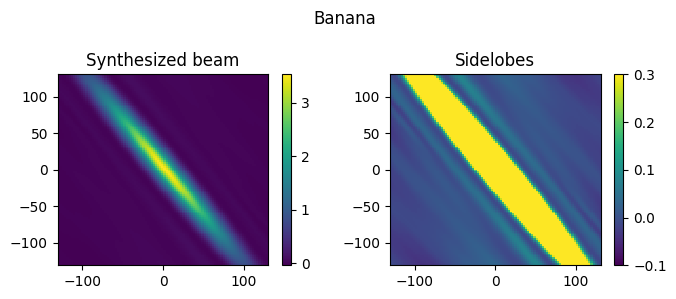

In [13]:
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("Banana")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()

### Rotation synthesis

We see the UV coverage changes depending on where the source is on the sky. To build up UV coverage a common strategy is to track a source as it moves through the sky. The primary beam of all dishes look at the same patch of the sky but the projected baseline lengths change.

In [45]:
#Let's start from the original point in time

nbl = uv.shape[0]
dtime = 1000
ntime = int(4*3600/dtime)  #grid every dtime sec for 4 hours. Not gridding it finely to save on your RAM size. Feel free to play with it.
uv_big = np.zeros((nbl*ntime,2),dtype='float64')

print("gridding for", ntime*dtime, "sec")
for i in range(ntime):
    sin_gha = np.sin(gha + i * dtime * 7.29e-5)
    cos_gha = np.cos(gha + i * dtime * 7.29e-5)
    rotmat = np.asarray([[sin_gha, cos_gha, 0],[-cos_gha*sin_dec, sin_gha*sin_dec, cos_dec]]).T
    uv_big[i*nbl:(i+1)*nbl] = hera_bl_xyz@rotmat

gridding for 14000 sec


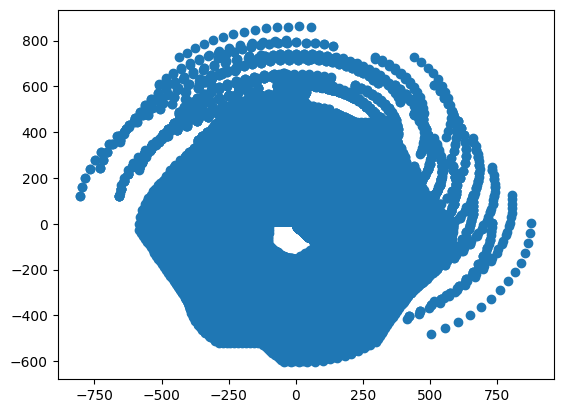

In [44]:
plt.scatter(uv_big[:,0], uv_big[:,1])

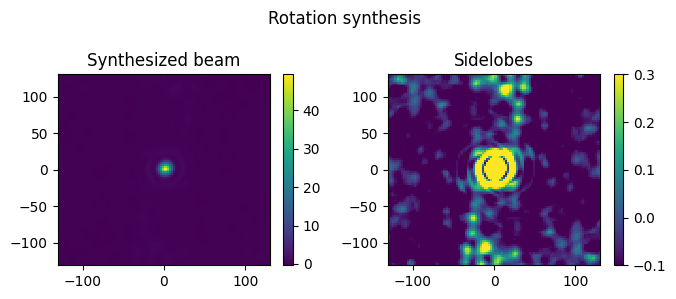

In [47]:
gridded_uv = grid_uv(uv_big, du, npix)
img = np.fft.ifft2(gridded_uv).real
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("Rotation synthesis")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()

Some of the big sidelobe holes have disappeared. Beam more compact.